In [1]:
from typing import Annotated
from langgraph.graph.message import add_messages
from pydantic import BaseModel
from langgraph.graph import StateGraph

In [2]:
class State(BaseModel):
    messages: Annotated[list, add_messages]

### notes

1. **Annotated** definition stored in email. add_messages is a reducer. Annotations can be ANY python object from a string to a function.
2. A reducer is used to define how multiple outputs will be combined. In a graph, imagine that outputs of 2 nodes converge and return [A] and [B] as states. Then to pass these as a combined state to 3rd node, what should be done --> this is what the **reducer** defines.
3. **add_messages** is a built-in reducer function that will add the 2 states i.e. [A,B] will be new state.
4. **START** and **END** (used below) are just the constants that indicate start and end of our work flow.

In [3]:
graph_builder = StateGraph(State)

In [4]:
import random

def our_first_node(old_state: State) -> State:

    reply = f"{random.choice(nouns)} are {random.choice(adjectives)}"
    messages = [{"role": "assistant", "content": reply}]

    new_state = State(messages=messages)

    return new_state

graph_builder.add_node("first_node", our_first_node)

In [6]:
from langgraph.graph import START, END

graph_builder.add_edge(START, "first_node")
graph_builder.add_edge("first_node", END)

### compiling (locking) and display the workflow

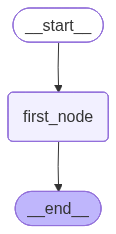

In [7]:
from IPython.display import display, Image

graph = graph_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [8]:
nouns = ["dog", "cat", "house", "computer", "river", "mountain", "book", "car", "friend", "teacher", "music", "story", "rain", "sun", "bird"]
adjectives = ["beautiful", "big", "small", "happy", "sad", "funny", "smart", "old", "young", "fast", "slow", "bright", "dark", "good", "bad", "new", "clean", "dirty", "loud", "quiet", "hard", "soft", "warm", "cold"]

In [9]:
start_state_1 = State(messages=["currently it does not matter what I enter here"])
result_1 = graph.invoke(start_state_1)
print(result_1["messages"][-1].content)
print("\n")
print(result_1)

dog are smart


{'messages': [HumanMessage(content='currently it does not matter what I enter here', additional_kwargs={}, response_metadata={}, id='162e2cbb-60f3-4609-8ec3-1a0c31733f03'), AIMessage(content='dog are smart', additional_kwargs={}, response_metadata={}, id='39ef0b6e-cb83-49b9-9068-e40a8e2dfd7f', tool_calls=[], invalid_tool_calls=[])]}


In [10]:
start_state_2 = State(messages=["you see?"])
result_2 = graph.invoke(start_state_2)
print(result_2["messages"][-1].content)
print("\n")
print(result_2)

bird are warm


{'messages': [HumanMessage(content='you see?', additional_kwargs={}, response_metadata={}, id='af41a93f-9d85-46e4-8445-061ad2f3b46c'), AIMessage(content='bird are warm', additional_kwargs={}, response_metadata={}, id='739b9f6e-1c35-44cf-b01f-a76b52904212', tool_calls=[], invalid_tool_calls=[])]}


### what happened above

1. langgraph took an initialized state.
2. It put it through the nodes (only 1 node in our case)
3. It returned the noun-adjective message
4. While returning though it wrapped it into it's own style with 2 messages - 1 human message and 1 AIMessage (currently not AI)

### using actual LLM

In [16]:
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI

print(load_dotenv(override=True))

True


In [14]:
llm_graph = StateGraph(State)

model = ChatOpenAI(model="gpt-4o-mini")

def llm_response(old_state : State) -> State:
    incoming_messages = old_state.messages
    result = model.invoke(incoming_messages)
    new_state = State(messages=[result])
    return new_state

llm_graph.add_node("llm_response", llm_response)
llm_graph.add_edge(START, "llm_response")
llm_graph.add_edge("llm_response", END)

compiled_llm_graph = llm_graph.compile()

start_state_1 = State(messages=[{"role": "user", "content": "Hello, how are you doing?"}])
compiled_llm_graph.invoke(start_state_1)

{'messages': [HumanMessage(content='Hello, how are you doing?', additional_kwargs={}, response_metadata={}, id='471099f8-ef27-406f-8965-08ebd285f193'),
  AIMessage(content="Hello! I'm just a computer program, so I don't have feelings, but I'm here and ready to help you. How can I assist you today?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 30, 'prompt_tokens': 14, 'total_tokens': 44, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_dbe198c320', 'id': 'chatcmpl-DIqaTMxnSCUBrbEGozvuMu0x1ypic', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019ce5f2-c7ff-7631-818e-8312447e43e4-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 14, 'o

<img src="images/image_1.png" width="300">

<img src="images/image_3.png" width="300">

<img src="images/image_2.png" width="350">

<img src="images/image_4.png" width="350">

### <u>some notes</u>

1. Above the creator explained a few more concepts of lang graph.
2. Super-step is 1 invocation of the graph from top to bottom i.e. 1 graph.invoke() call.
3. Each time user has a query, 1 super-step is executed.
4. Checkpoints is provided by LG to save the memory after each super-step.

### <u>langsmith as explained by gpt</u>

<img src="images/image_5.png" width="500">

<img src="images/image_6.png" width="500">

<img src="images/image_7.png" width="500">

<img src="images/image_8.png" width="500">

In [17]:
from langchain_community.utilities import GoogleSerperAPIWrapper

serper = GoogleSerperAPIWrapper()
serper.run("What is the capital of France?")

'Paris is the capital and largest city of France, with an estimated city population of 2.04 million in an area of 105.4 km2 (40.7 sq mi), and a metropolitan ... Paris, city and capital of France, located along the Seine River, in the north-central part of the country. Paris is one of the world\'s most ... Paris, the capital of France, is located in the north- central part of the country along the Seine River. Known as "The City of Light," Paris is ... Paris is the capital and most populous city of France. Situated on the Seine River, in the north of the country, it is in the centre of the Île-de-France ... Its capital, largest city and main cultural and economic centre is Paris. Metropolitan France was settled during the Iron Age by Celtic tribes known as Gauls ... Do you know what city is called the \'City of Light\'? Join us for this exciting quiz where we uncover the capital of France! The capital and by far the most important city of France is Paris, one of the world\'s preeminent 

### langchain_core.agents.Tool

Wrapper to convert a python function to tool.

In [21]:
from langchain_core.tools import Tool

online_search_tool = Tool(name="search", func=serper.run, description="used to search online when information is required.")

# online_search_tool.invoke("what is the capital of france?")

### Graph that uses 2 tools

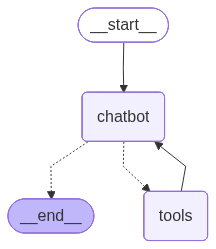

In [28]:
from typing import TypedDict
from langgraph.prebuilt import ToolNode, tools_condition

class graph2State(TypedDict):
    messages: Annotated[list, add_messages]

graph_with_two_tools = StateGraph(graph2State)

# tool 1 : online_search_tool

def tool2func(text):
    """ send message to the user """
    print(f"Sending the message : {text}")
    return f"Sending the message : {text}"

tool_2 = Tool(name="send_message", func=tool2func, description="Function that sends a message to the user.")

tools = [online_search_tool, tool_2]

model = ChatOpenAI(model="gpt-4o-mini")
model_with_tools = model.bind_tools(tools)

def chatbot(state: graph2State):
    incoming_messages = state["messages"]
    model_result = model_with_tools.invoke(incoming_messages)
    outgoing_state = graph2State(messages=model_result)
    return outgoing_state

graph_with_two_tools.add_node("chatbot", chatbot)
graph_with_two_tools.add_node("tools", ToolNode(tools=tools))

graph_with_two_tools.add_conditional_edges("chatbot", tools_condition, "tools")
graph_with_two_tools.add_edge("tools", "chatbot")
graph_with_two_tools.add_edge(START, "chatbot")
# No need to add edge to END. Langgraph understands it implicitly

graph_with_two_tools_compiled = graph_with_two_tools.compile()
display(Image(graph_with_two_tools_compiled.get_graph().draw_mermaid_png()))

### putting in gradio chat

In [29]:
import gradio as gr

def chat(user_input: str, history):
    result = graph_with_two_tools_compiled.invoke({"messages": [{"role": "user", "content": user_input}]})
    return result["messages"][-1].content

gr.ChatInterface(chat).launch()

* Running on local URL:  http://127.0.0.1:7862
* To create a public link, set `share=True` in `launch()`.


Sending the message : Madhuri Dixit Nene, born on May 15, 1967, in Mumbai, India, is a renowned Indian actress and television personality. She made her acting debut at the age of 17 in the film "Abodh" and has since appeared in over 70 Hindi films. Madhuri is celebrated for her performances and is also a trained Kathak dancer. She hails from a Marathi Brahmin family and has significantly contributed to Indian cinema, gaining immense recognition for her roles in various films. Additionally, she is known for her charm and vibrant dance performances.


### next

Tool calling code is very abstracted away. Lot going on. Need to understand more.